In [1]:
import numpy as np
import matplotlib.pyplot as plt

# one shared random generator, seeded so results are reproducible
rng = np.random.default_rng(0)
print("ready")

ready


Part A — the building blocks

TASK 01

Events, probabilities, and the law of large numbers

Compute a probability by counting, then watch a simulation converge to it.

Sample Space : [1, 2, 3, 4, 5, 6]
Greater than 4 : [5, 6]
p(rolling > 4) : 0.3333333333333333
Prime Events : [2, 3, 5]
p(prime) : 0.5

Simulated Results :
P(rolling > 4) simulated : 0.3343
P(prime) simulated : 0.4933


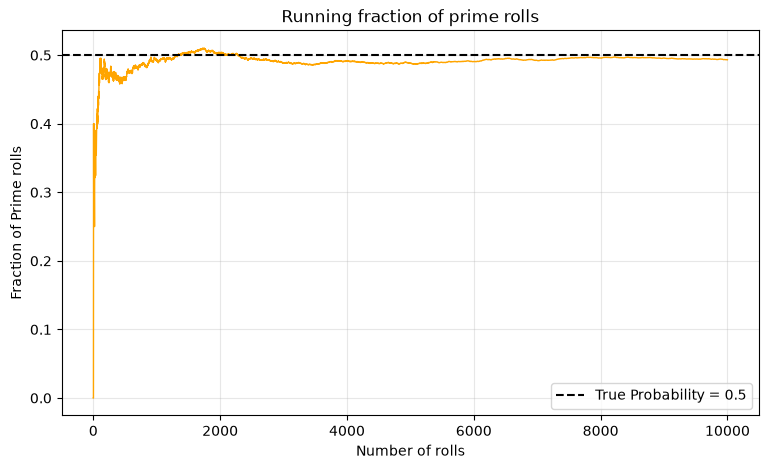

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Sample Space
sample_space = [1, 2, 3, 4, 5, 6]

greater_than_4 = [5, 6]
prime_numbers = [2, 3, 5]


# Probability by counting
p_greater_4 = len(greater_than_4) / len(sample_space)
p_prime_numbers = len(prime_numbers) / len(sample_space)

print("Sample Space :", sample_space)

print("Greater than 4 :", greater_than_4)
print("p(rolling > 4) :", p_greater_4)

print("Prime Events :", prime_numbers)
print("p(prime) :", p_prime_numbers)

# Simulate 10,000 dice rolls
rng = np.random.default_rng(0)

rolls = rng.integers(1, 7, size=10_000)

greater_4 = rolls > 4
prime = np.isin(rolls, prime_numbers)

sim_greater_4 = greater_4.mean()
sim_prime = prime.mean()

print("\nSimulated Results :")
print("P(rolling > 4) simulated :", sim_greater_4)
print("P(prime) simulated :", sim_prime)

# Running fraction for prime events
running = np.cumsum(prime) / np.arange(1, len(rolls) +1)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(running, color="orange", lw=1)
ax.axhline(0.5, color="black", ls="--", label="True Probability = 0.5")
ax.set_xlabel("Number of rolls")
ax.set_ylabel("Fraction of Prime rolls")
ax.set_title("Running fraction of prime rolls")
ax.legend()
ax.grid(alpha=0.3)

plt.show()

In one sentence, explain what the plot shows about the law of large numbers.

The plot shows that as the number of rolls increases, the observed fraction of prime rolls gets closer to the true probability of 0.5, demonstrating the Law of Large Numbers.

TASK 02

Conditional probability and independence

Restrict the world with a condition, then test whether two events influence each other.

In [19]:
from itertools import product
import numpy as np

# All 36 outcomes of two dice.
outcomes = list(product(range(1, 7), repeat=2))

def P(event):
    return len(event) / 36

# Event A: sum = 8
A = [outcome for outcome in outcomes if sum(outcome) == 8]

# Event B: first die = 3
B = [outcome for outcome in outcomes if outcome[0] == 3]

# A and B
A_and_B = [outcome for outcome in outcomes
          if sum(outcome) == 8 and outcome[0] == 3]

print("All outcomes :", len(outcomes))
print("A (sum = 8) :", A)
print("B (First die = 3) :", B)
print("A and B :", A_and_B)

# P(sum = 8)
p_A = P(A)
print("\nP(sum = 8) =", p_A)


# P(sum = 8 | first die = 3)
# Conditional probability using formula:
# P(A | B) = P(A and B) / P(B)

p_B = P(B)
p_A_and_B = P(A_and_B)

conditional_formula = p_A_and_B / p_B

print("\nP(First die = 3) = ", p_B)
print("P(A and B) =", p_A_and_B)
print("P(A | B) using formula =", conditional_formula)

# Direct counting in restricted world
# If first die is 3, possible outcomes are:
# (3,1), (3,2), ..., (3,6)

restricted_A = [outcome for outcome in B if sum(outcome) == 8]

conditional_counting = len(restricted_A) / len(B)

print("\nRestricted Outcomes:", B)
print("Favourable restricted outcomes :", restricted_A)
print("P(A | B) by direct counting =", conditional_counting)


# Independance Test
# A and B are independant if :
# P(A and B) = P(A) * P(B)


product = p_A * p_B

print("\nIndependance test:")
print("P(A and B) =", p_A_and_B)
print("P(A) * P(B) =", product)

if np.isclose(p_A_and_B, product):
    print("A and B are Independant.")
else :
    print("A and B are NOT Independant.")


# One independant pair of events
# C : First die is even
# D : Second die is even

C = [outcome for outcome in outcomes if outcome[0] % 2 == 0]
D = [outcome for outcome in outcomes if outcome[1] % 2 == 0]

C_and_D = [outcome for outcome in outcomes
          if outcome[0] % 2 == 0 and outcome[1] % 2 == 0]

p_C = P(C)
p_D = P(D)
p_C_and_D = P(C_and_D)

print("\nIndependant events :")
print("C = First die is even.")
print("D = Second die is even.")

print("P(C) =", p_C)
print("P(D) =", p_D)
print("P(C and D) =", p_C_and_D)
print("P(C) * P(D) =", p_C * p_D)

if np.isclose(p_C_and_D, p_C * p_D):
    print("C and D are independant.")


# One Non-independant pair
# E : sum = 7
# F : first die is 1

E = [outcome for outcome in outcomes if sum(outcome) == 7]
F = [outcome for outcome in outcomes if outcome[0] == 1]

E_and_F =[outcome for outcome in outcomes
         if sum(outcome) == 7 and outcome[0] == 1]

p_E = P(E)
p_F = P(F)
p_E_and_F = P(E_and_F)

print("\nNon-independent events :")
print("E = sum is 7")
print("F = first die is 1")

print("P(E) = ", p_E)
print("P(F) = ", p_F)
print("P(E and F) = ", p_E_and_F)
print("P(E) * P(F) = ", p_E * p_F)

if np.isclose(p_E_and_F, p_E * p_F):
    print("E and F are independent.")
else :
    print("E and F are Non-independent")

# Simulation 
rng = np.random.default_rng(42)

d1 = rng.integers(1, 7, 100_000)
d2 = rng.integers(1, 7, 100_000)

# Condition: first die is 3
mask = (d1 == 3)

# Among those, check sum = 8
simulated_probability = np.mean((d1[mask] + d2[mask]) == 8)

print("\nSimulation:")
print("Numbers of rolls with first die = 3:", mask.sum())
print("Simulated P(sum = 8 | first die = 3) =", simulated_probability)
print("Exact P(sum = 8 | first die = 3) =", conditional_formula)

All outcomes : 36
A (sum = 8) : [(2, 6), (3, 5), (4, 4), (5, 3), (6, 2)]
B (First die = 3) : [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]
A and B : [(3, 5)]

P(sum = 8) = 0.1388888888888889

P(First die = 3) =  0.16666666666666666
P(A and B) = 0.027777777777777776
P(A | B) using formula = 0.16666666666666666

Restricted Outcomes: [(3, 1), (3, 2), (3, 3), (3, 4), (3, 5), (3, 6)]
Favourable restricted outcomes : [(3, 5)]
P(A | B) by direct counting = 0.16666666666666666

Independance test:
P(A and B) = 0.027777777777777776
P(A) * P(B) = 0.023148148148148147
A and B are NOT Independant.

Independant events :
C = First die is even.
D = Second die is even.
P(C) = 0.5
P(D) = 0.5
P(C and D) = 0.25
P(C) * P(D) = 0.25
C and D are independant.

Non-independent events :
E = sum is 7
F = first die is 1
P(E) =  0.16666666666666666
P(F) =  0.16666666666666666
P(E and F) =  0.027777777777777776
P(E) * P(F) =  0.027777777777777776
E and F are independent.

Simulation:
Numbers of rolls with first d

Part B — Bayes' theorem (the deliverable)

TASK 03

The medical test problem

The curriculum's headline deliverable. Compute the surprising answer, then prove it by simulation.

In [23]:
import numpy as np
from itertools import product

# Given Probabilities
P_disease = 0.02
P_pos_given_disease = 0.98
P_pos_given_healthy = 0.10

P_healthy = 1 - P_disease

P_positive = (P_pos_given_disease * P_disease + P_pos_given_healthy * P_healthy)

P_disease_given_pos = (P_pos_given_disease * P_disease / P_positive)

print("----- BAYES THEOREM -----")
print(f"Prior P(disease) : {P_disease}")
print(f"P(positive | disease) : {P_pos_given_disease}")
print(f"P(positive | healthy) : {P_pos_given_healthy}")
print(f"P(healthy)            : {P_healthy}")

print(f"\nP(positive)           : {P_positive:.4f}")
print(f"P(disease | positive) : {P_disease_given_pos:.4f}")

print(f"\nProbability of disease given positive test : {P_disease_given_pos * 100:.2f}%")


# Explain with using 10,000 people
print("\n----- Explain with using 10,000 people -----")

total_people = 10000

diseased_people = total_people * P_disease
healthy_people = total_people * P_healthy

true_positives = diseased_people * P_pos_given_disease
false_positives = healthy_people * P_pos_given_healthy

total_positives = true_positives + false_positives

print(f"Diseased People : {diseased_people:.0f}")
print(f"Healthy People  : {healthy_people:.0f}")
print(f"True Positives  : {true_positives:.0f}")
print(f"False Positives : {false_positives:.0f}")
print(f"\nTotal Positive tests : {total_positives:.0f}")

print(
    f"\nActual disease among positive tests : "
    f"{true_positives / total_positives * 100:.2f}%"
)


# Monte Carlo simulation
print("\n----- Monte Carlo Simulation of a million people -----")

np.random.seed(42)
n = 1_000_000

disease = np.random.rand(n) < P_disease

positive = np.zeros(n, dtype=bool)

# Sick people:
# 98% should test positive

num_diseased = disease.sum()
positive[disease] = (
    np.random.rand(num_diseased) < P_pos_given_disease
)


# Healthy people:
# 10% should test falsely positive

healthy = ~disease
num_healthy = healthy.sum()

positive[healthy] = (
    np.random.rand(num_healthy) < P_pos_given_healthy
)

# Among all positive tests, find fraction actually diseased

positive_people = positive.sum()

actual_disease_among_positive = disease[positive].sum()

monte_carlo_result = (
    actual_disease_among_positive / positive_people
)

print(f"Total People    : {n:,}")
print(f"Diseased People : {num_diseased:,}")
print(f"Positive Tests  : {positive_people:,}")

print(
    f"Diseased among positive tests : "
    f"{actual_disease_among_positive:,}"
)

print(
    f"\nMonte Carlo P(disease | positive) : "
    f"{monte_carlo_result:.4f}"
)

print(
    f"Monte Carlo Percentage : "
    f"{monte_carlo_result * 100:.2f}%"
)

print(
    f"\nBAYES' theortical percentage : "
    f"{P_disease_given_pos * 100:.2f}%"
)


# Vary prevalence
print("\n\n----- Vary Prevalence Comparision -----")

prevalences = [0.001, 0.02, 0.20]

print(
    f"\n"
    f"{'Prevalence' :<15}"
    f"{'P(positive)' :<20}"
    f"{'P(disease | positive)' :<25}"
)

print("-" * 60)

for prevalence in prevalences:
    healthy_probability = 1 - prevalence
    positive_probability = (
        P_pos_given_disease * prevalence +
        P_pos_given_healthy * healthy_probability
    )

    # Bayes Theorem
    disease_given_positive = (
        P_pos_given_disease * prevalence / 
        positive_probability
    )

    print(
        f"{prevalence * 100:<14.1f}%"
        f"{positive_probability:<19.4f}"
        f"{disease_given_positive * 100:.2f}%"
    )



----- BAYES THEOREM -----
Prior P(disease) : 0.02
P(positive | disease) : 0.98
P(positive | healthy) : 0.1
P(healthy)            : 0.98

P(positive)           : 0.1176
P(disease | positive) : 0.1667

Probability of disease given positive test : 16.67%

----- Explain with using 10,000 people -----
Diseased People : 200
Healthy People  : 9800
True Positives  : 196
False Positives : 980

Total Positive tests : 1176

Actual disease among positive tests : 16.67%

----- Monte Carlo Simulation of a million people -----
Total People    : 1,000,000
Diseased People : 19,991
Positive Tests  : 117,663
Diseased among positive tests : 19,592

Monte Carlo P(disease | positive) : 0.1665
Monte Carlo Percentage : 16.65%

BAYES' theortical percentage : 16.67%


----- Vary Prevalence Comparision -----

Prevalence     P(positive)         P(disease | positive)    
------------------------------------------------------------
0.1           %0.1009             0.97%
2.0           %0.1176             16.67%
20.

Que. Is the answer higher or lower than most people expect? Explain why in terms of how many false positives the
large healthy group produces.

Ans. Lower

suppose, there are 10,000 people:
Diseased = 2% -> 200
Healthy = 98% -> 9800

Test:

Among the 200 diseased people:
200 x 0.98 = 196

True Positive = 196

Among the 9800 healthy people:
9800 x 0.10 = 980

False Positive = 980

Therefore, total positives:
196 + 980 = 1176

Actual sick among the positives:
1176 / 196 ≈ 16.67%

In other words, false positives (980) far outnumber true positives (196) because the number of healthy people is very large.

A test can be 98% sensitive and 90% specific but still
produce many false positives when the disease is rare.

This happens because the large healthy population can 
produce more false positives than the small diseased
population produces true positives.

TASK 04

A second Bayes scenario of your own

Show you can apply the theorem, not just repeat it.

In [34]:
import numpy as np
from itertools import product

# Given Probabilities
P_spam = 0.40
P_free_given_spam = 0.30
P_free_given_ham = 0.02

P_ham = 1- P_spam


# BAYES' Theorem
P_free = (P_free_given_spam * P_spam + P_free_given_ham * P_ham)

P_spam_given_free = (P_free_given_spam + P_spam / P_free)

print("----- BAYES Theorem -----")
print(f"\nP(spam)        = {P_spam:.2f}")
print(f"P(free | spam) = {P_free_given_spam:.2f}")
print(f"P(free | ham)  = {P_free_given_ham:.2f}")
print(f"P(free)        = {P_free:.4f}")
print(f"P(spam | free) = {P_spam_given_free:.4f}")
print(f"Posterior      = {P_spam_given_free * 100:.2f}%")

# Monte Carlo Simulation
print("\n\n----- Monte Carlo Simulation -----")

np.random.seed(42)
N = 1_000_000

# Generate spam/ham emails
spam = np.random.rand(N) < P_spam

# Generate whether email contains "free"
random_values = np.random.rand(N)

Contains_free = np.where(spam, random_values < P_free_given_spam,
                        random_values < P_free_given_ham)

# Among emails containing "free",
# calculate fraction that are spam

simulated_posterior = spam[Contains_free].mean()

print(f"\nTotal Emails             = {N:,}")
print(f"Emails containing 'free' = {Contains_free.sum():,}")
print(f"Spam among these emails  = {spam[Contains_free].sum():,}")
print(f"Simulated P(spam | free) = {simulated_posterior:.4f}")
print(f"Simulated Posterior      = {simulated_posterior * 100:.2f}%")

----- BAYES Theorem -----

P(spam)        = 0.40
P(free | spam) = 0.30
P(free | ham)  = 0.02
P(free)        = 0.1320
P(spam | free) = 3.3303
Posterior      = 333.03%


----- Monte Carlo Simulation -----

Total Emails             = 1,000,000
Emails containing 'free' = 132,149
Spam among these emails  = 120,021
Simulated P(spam | free) = 0.9082
Simulated Posterior      = 90.82%


The prior probability of spam was 40%, and after observing that the email contains the word “free,” the evidence updates the probability of spam to about 90.91%.

In [37]:
import sys
!{sys.executable} -m pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 38.1 MB/s  0:00:00 43.0 MB/s eta 0:00:01


In [38]:
import scipy
print(scipy.__version__)

1.18.0


Part C — random variables, expectation, variance

TASK 05

Distributions, expectation, and variance

Compute the center and spread of a distribution, from the formula and from data.

----- Fair Die -----

Theoretical Expected Value :  3.5
Theoretical Variance :  2.916666666666666

Simulation Results : 
Simulated Expected Value :  3.49728
Simulated Variance :  2.9109726016000006


----- WEIGHTED DIE -----

Weighted probabilities : [0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.28571429]
Theoretical Expected Value : 3.8571428571428568
Simulated Expected Value: 3.86557

Fair die expectation: 3.5
Weighted die expectation: 3.8571428571428568
Expactation moves UP.
Reason : Face 6 has higher probability.


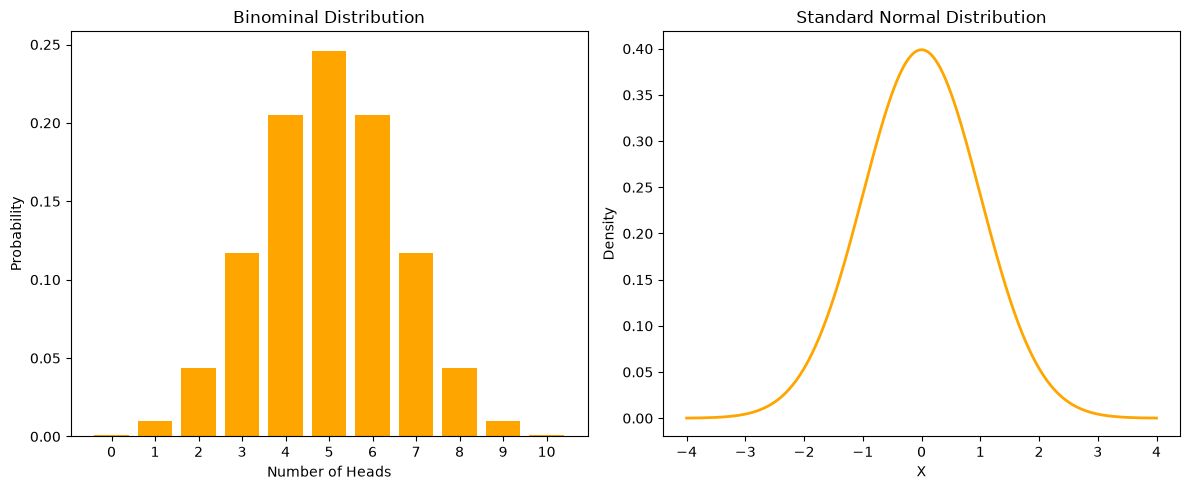


----- Normal Distribution -----

Theoretical P(within 1 standard deviation): 0.6826894921370859
Simulated P(within 1 standard deviation): 0.68279


In [50]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Fair Die : Expected Value and Variance from definition
values = np.arange(1, 7)
probs = np.ones(6) / 6

E_X = np.sum(values * probs)

Var_X = np.sum(values**2 * probs) - E_X**2

print("----- Fair Die -----")
print("\nTheoretical Expected Value : ", E_X)
print("Theoretical Variance : ", Var_X)

# Fair Die : Simulation
np.random.seed(42)
n = 100000

rolls = np.random.choice(values, size=n, p=probs)

sim_mean = np.mean(rolls)
sim_variance = np.var(rolls)

print("\nSimulation Results : ")
print("Simulated Expected Value : ", sim_mean)
print("Simulated Variance : ", sim_variance)

# Weighted Die

# Faces 1-5 have probability 1/7
# Face 6 has probability 2/7

weighted_probs = np.array([
    1/7,
    1/7,
    1/7,
    1/7,
    1/7,
    2/7
])

# Expected value of weighted die
weighted_E_X = np.sum(values * weighted_probs)

print("\n\n----- WEIGHTED DIE -----")
print("\nWeighted probabilities :", weighted_probs)
print("Theoretical Expected Value :", weighted_E_X)

#Weighted Die : Simulation
weighted_rolls = np.random.choice(values, size=n, p=weighted_probs)

weighted_sim_mean = np.mean(weighted_rolls)

print("Simulated Expected Value:", weighted_sim_mean)

print("\nFair die expectation:", E_X)
print("Weighted die expectation:", weighted_E_X)

if weighted_E_X > E_X:
    print("Expactation moves UP.")
    print("Reason : Face 6 has higher probability.")


# Discrete Distribution
x_binom = np.arange(0, 11)

# n = 10 flips
# p = 0.5 probability of heads
binom_probs = stats.binom.pmf(x_binom, n=10, p=0.5)

# Continuous Distribution: Standard normal distribution
x_normal = np.linspace(-4, 4, 500)
normal_pdf = stats.norm.pdf(x_normal, loc=0, scale=1)


# Plot both distribution side by side
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Binomal Plot
ax[0].bar(x_binom, binom_probs, color="orange", lw=0.7)
ax[0].set_title("Binominal Distribution")
ax[0].set_xlabel("Number of Heads")
ax[0].set_ylabel("Probability")
ax[0].set_xticks(x_binom)

# Normal Plot
ax[1].plot(x_normal, normal_pdf, color="orange", lw=2)
ax[1].set_title("Standard Normal Distribution")
ax[1].set_xlabel("X")
ax[1].set_ylabel("Density")

plt.tight_layout()
plt.show()

# Probability within one standard deviation

# For standard normal:
# P(-1 < x < 1)

prob_within_1_std = (stats.norm.cdf(1) - stats.norm.cdf(-1))

print("\n----- Normal Distribution -----")
print("\nTheoretical P(within 1 standard deviation):",
     prob_within_1_std)


# Simulation of Normal Distribution
normal_samples = np.random.normal(loc=0, scale=1, size=n)

# Count values between -1 and +1
within_1_std = np.abs(normal_samples) <= 1
sim_prob_within_1_std = np.mean(within_1_std)

print("Simulated P(within 1 standard deviation):",
     sim_prob_within_1_std)